# 02. Análise Exploratória de Dados

Este notebook tem como objetivo explorar os dados processados, avaliar qualidade, distribuições, outliers, padrões de engajamento e sinais associados à conversão de ofertas.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

## 2. Leitura dos datasets processados

In [3]:
customers = pd.read_parquet("../data/processed/customers_clean.parquet")
offers = pd.read_parquet("../data/processed/offers_clean.parquet")
transactions = pd.read_parquet("../data/processed/transactions_clean.parquet")
customer_features = pd.read_parquet("../data/processed/customer_features.parquet")
customer_offer_interactions = pd.read_parquet("../data/processed/customer_offer_interactions.parquet")
offers_channels = pd.read_parquet("../data/processed/offers_channels.parquet")

## 3. Visão geral dos datasets

In [5]:
datasets = {
    "customers": customers,
    "offers": offers,
    "transactions": transactions,
    "customer_features": customer_features,
    "customer_offer_interactions": customer_offer_interactions,
    "offers_channels": offers_channels
}

for name, df in datasets.items():
    print("=" * 60)
    print(name.upper())
    print("=" * 60)
    print(f"Shape: {df.shape}")
    display(df.head())
    print("\n")

CUSTOMERS
Shape: (17000, 6)


,age,credit_card_limit,gender,id,registered_on,account_age_days
0,NaN,NaN,unknown,68be06ca386d4c31939f3a4f0e3dd783,2017-02-12,3378
1,55.0,112000.0,F,0610b486422d4921ae7d2bf64640c50b,2017-07-15,3225
2,NaN,NaN,unknown,38fe809add3b4fcf9315a9694bb96ff5,2018-07-12,2863
3,75.0,100000.0,F,78afa995795e4d85b5d9ceeca43f5fef,2017-05-09,3292
4,NaN,NaN,unknown,a03223e636434f42ac4c3df47e8bac43,2017-08-04,3205




OFFERS
Shape: (10, 11)


,channels,discount_value,duration,id,min_value,offer_type,duration_days,num_channels,is_bogo,is_discount,is_informational
0,"[email, mobile, social]",10.0,7.0,ae264e3637204a6fb9bb56bc8210ddfd,10.0,bogo,7,3,1,0,0
1,"[web, email, mobile, social]",10.0,5.0,4d5c57ea9a6940dd891ad53e9dbe8da0,10.0,bogo,5,4,1,0,0
2,"[web, email, mobile]",0.0,4.0,3f207df678b143eea3cee63160fa8bed,0.0,informational,4,3,0,0,1
3,"[web, email, mobile]",5.0,7.0,9b98b8c7a33c4b65b9aebfe6a799e6d9,5.0,bogo,7,3,1,0,0
4,"[web, email]",5.0,10.0,0b1e1539f2cc45b7b9fa7c272da2e1d7,20.0,discount,10,2,0,1,0




TRANSACTIONS
Shape: (306534, 6)


...

,age,credit_card_limit,gender,id,registered_on,account_age_days,total_transactions,total_spent,avg_ticket,min_ticket,max_ticket,first_transaction_day,last_transaction_day,recency_days,offers_received,offers_viewed,offers_completed,distinct_offers,view_rate,completion_rate
0,62.0,73000.0,M,c05652fa9d2c4fac9a010ea5a9310c86,2018-01-27,3029,7,27.23,3.890000,0.80,7.47,3.0,27.0,2.0,6,4,1,5,0.666667,0.166667
1,42.0,57000.0,M,6be0513109fe4d738e2af7fb252fefb7,2018-06-13,2892,3,40.05,13.350000,12.77,13.74,18.0,27.0,2.0,4,3,1,3,0.750000,0.250000
2,NaN,NaN,unknown,9de54389816342449e445db1d75d341d,2018-04-22,2944,1,6.10,6.100000,6.10,6.10,15.0,15.0,14.0,3,2,0,2,0.666667,0.000000
3,48.0,75000.0,M,f5de20984950433d9c206f7c42477342,2015-09-10,3899,16,323.65,20.228125,10.40,28.66,2.0,29.0,0.0,4,4,4,2,1.000000,1.000000
4,49.0,36000.0,F,9da3f2339b244229a8337572e982b189,2018-01-09,3047,4,18.87,4.717500,3.03,8.39,0.0,22.0,7.0,5,2,1,4,0.400000,0.200000




CUSTOMER_OFFER_INTERACTIONS
Shape: (115609, 37)


,account_id,offer_id,offer_received_day,offer_viewed_day,offer_completed_day,reward_received,was_viewed,was_completed,age,credit_card_limit,gender,registered_on,account_age_days,total_transactions,total_spent,avg_ticket,min_ticket,max_ticket,first_transaction_day,last_transaction_day,recency_days,offers_received,offers_viewed,offers_completed,distinct_offers,view_rate,completion_rate,channels,discount_value,duration,min_value,offer_type,duration_days,num_channels,is_bogo,is_discount,is_informational
0,0020ccbbb6d84e358d3414a3ff76cffd,9b98b8c7a33c4b65b9aebfe6a799e6d9,21,24.0,25.0,5.0,1,1,24.0,60000.0,F,2016-11-11,3471,12,154.05,12.8375,6.81,20.08,1.0,28.0,1.0,4,4,3,4,1.0,0.75,"[web, email, mobile]",5.0,7.0,5.0,bogo,7,3,1,0,0
1,0020ccbbb6d84e358d3414a3ff76cffd,2298d6c36e964ae4a3e7e9706d1fb8c2,7,7.0,9.0,3.0,1,1,24.0,60000.0,F,2016-11-11,3471,12,154.05,12.8375,6.81,20.08,1.0,28.0,1.0,4,4,3,4,1.0,0.75,"[web, email, mobile, social]",3.0,7.0,7.0,discount,7,4,0,1,0
2,0020ccbbb6d84e358d3414a3ff76cffd,f19421c1d4aa40978ebb69ca19b0e20d,14,14.0,15.0,5.0,1,1,24.0,60000.0,F,2016-11-11,3471,12,154.05,12.8375,6.81,20.08,1.0,28.0,1.0,4,4,3,4,1.0,0.75,"[web, email, mobile, social]",5.0,5.0,5.0,bogo,5,4,1,0,0
3,0020ccbbb6d84e358d3414a3ff76cffd,5a8bc65990b245e5a138643cd4eb9837,17,17.0,NaN,NaN,1,0,24.0,60000.0,F,2016-11-11,3471,12,154.05,12.8375,6.81,20.08,1.0,28.0,1.0,4,4,3,4,1.0,0.75,"[email, mobile, social]",0.0,3.0,0.0,informational,3,3,0,0,1
4,00426fe3ffde4c6b9cb9ad6d077a13ea,0b1e1539f2cc45b7b9fa7c272da2e1d7,14,NaN,NaN,NaN,0,0,19.0,65000.0,F,2016-08-09,3565,17,68.51,4.0300,0.37,16.97,1.0,29.0,0.0,5,2,1,4,0.4,0.20,"[web, email]",5.0,10.0,20.0,discount,10,2,0,1,0




OFFERS_CHANNELS
Shape: (33, 3)


,id,offer_type,channel
0,ae264e3637204a6fb9bb56bc8210ddfd,bogo,email
1,ae264e3637204a6fb9bb56bc8210ddfd,bogo,mobile
2,ae264e3637204a6fb9bb56bc8210ddfd,bogo,social
3,4d5c57ea9a6940dd891ad53e9dbe8da0,bogo,web
4,4d5c57ea9a6940dd891ad53e9dbe8da0,bogo,email


## 4. Tipagem e valores ausentes

In [6]:
for name, df in datasets.items():
    print("=" * 60)
    print(name.upper())
    print("=" * 60)

    print("Tipos das colunas:")
    display(df.dtypes)

    nulls = df.isnull().sum().sort_values(ascending=False)
    nulls_percent = (nulls / len(df) * 100).round(2)

    print("Valores ausentes:")
    display(
        pd.DataFrame({
            "nulls": nulls,
            "percent": nulls_percent
        })
    )

CUSTOMERS
Tipos das colunas:


age                  float64
credit_card_limit    float64
gender                object
id                    object
registered_on         object
account_age_days       int32
dtype: object

Valores ausentes:


,nulls,percent
age,2192,12.89
credit_card_limit,2175,12.79
gender,0,0.00
id,0,0.00
registered_on,0,0.00
account_age_days,0,0.00


OFFERS
Tipos das colunas:


...

,nulls,percent
offer_completed_day,48212,41.70
reward_received,48212,41.70
offer_viewed_day,16676,14.42
age,13038,11.28
credit_card_limit,12916,11.17
first_transaction_day,2364,2.04
recency_days,2364,2.04
last_transaction_day,2364,2.04
discount_value,0,0.00
distinct_offers,0,0.00


OFFERS_CHANNELS
Tipos das colunas:


id            object
offer_type    object
channel       object
dtype: object

Valores ausentes:


,nulls,percent
id,0,0.0
offer_type,0,0.0
channel,0,0.0


### Observação

A análise inicial de estrutura e valores ausentes permite verificar se o processamento dos dados foi realizado corretamente e se existem campos que exigem tratamento adicional antes da modelagem.

# 5. Análise de clientes

## 5.1 Estatísticas descritivas

In [7]:
customers.describe(include="all")

,age,credit_card_limit,gender,id,registered_on,account_age_days
count,14808.000000,14825.000000,17000,17000,17000,17000.000000
unique,NaN,NaN,4,17000,1716,NaN
top,NaN,NaN,M,68be06ca386d4c31939f3a4f0e3dd783,2017-12-07,NaN
freq,NaN,NaN,8484,1,43,NaN
mean,54.340829,65404.991568,NaN,NaN,NaN,3366.449882
std,17.323921,21598.299410,NaN,NaN,NaN,411.223904
min,18.000000,30000.000000,NaN,NaN,NaN,2849.000000
25%,42.000000,49000.000000,NaN,NaN,NaN,3057.000000
50%,55.000000,64000.000000,NaN,NaN,NaN,3207.000000
75%,66.000000,80000.000000,NaN,NaN,NaN,3640.000000


## 5.2 Distribuição de idade

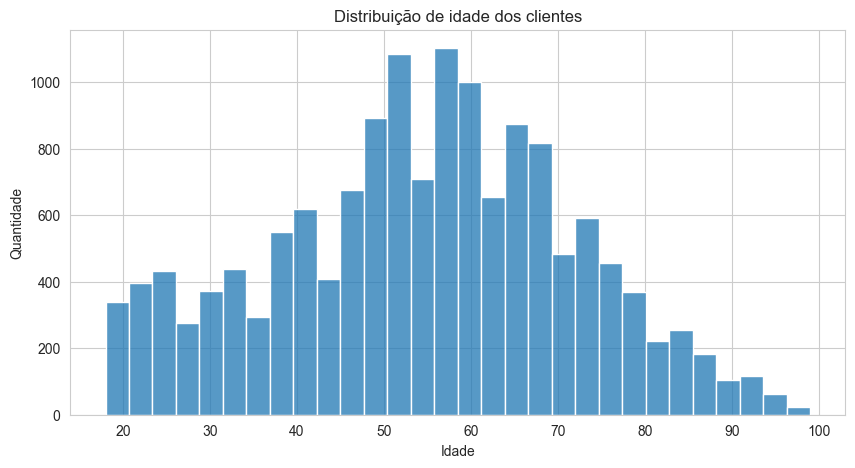

In [8]:
plt.figure(figsize=(10, 5))

sns.histplot(
    customers["age"],
    bins=30
)

plt.title("Distribuição de idade dos clientes")
plt.xlabel("Idade")
plt.ylabel("Quantidade")

plt.show()

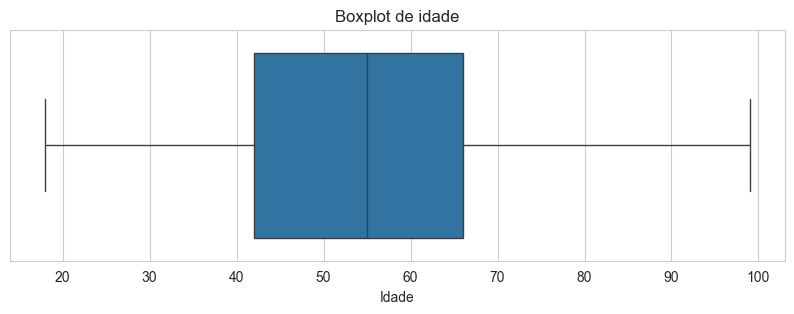

In [9]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    x=customers["age"]
)

plt.title("Boxplot de idade")
plt.xlabel("Idade")

plt.show()

### Observação

A distribuição de idade ajuda a avaliar a composição demográfica da base e a identificar possíveis valores extremos ou concentrações relevantes para segmentação futura.

## 5.3 Distribuição do limite de crédito

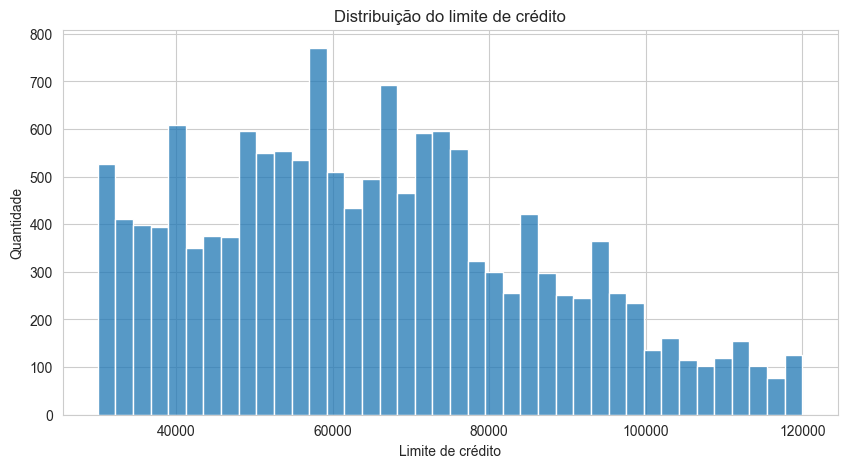

In [10]:
plt.figure(figsize=(10, 5))

sns.histplot(
    customers["credit_card_limit"],
    bins=40
)

plt.title("Distribuição do limite de crédito")
plt.xlabel("Limite de crédito")
plt.ylabel("Quantidade")

plt.show()

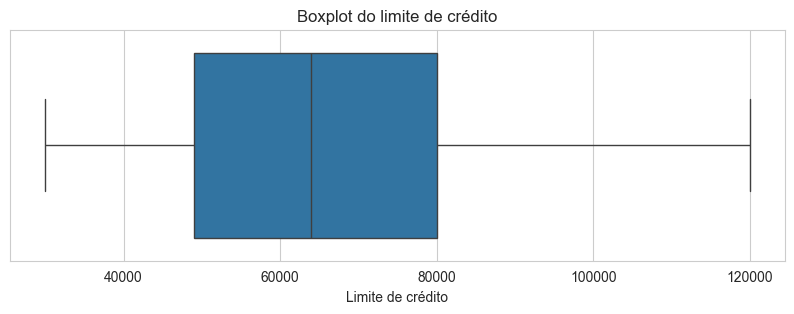

In [11]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    x=customers["credit_card_limit"]
)

plt.title("Boxplot do limite de crédito")
plt.xlabel("Limite de crédito")

plt.show()

### Observação

O limite de crédito tende a apresentar assimetria à direita, sugerindo a existência de clientes com maior potencial financeiro. Essa variável pode ser relevante para diferenciar perfis de consumo.

## 5.4 Distribuição por gênero

In [12]:
customers["gender"].value_counts(dropna=False)

gender
M          8484
F          6129
unknown    2175
O           212
Name: count, dtype: int64

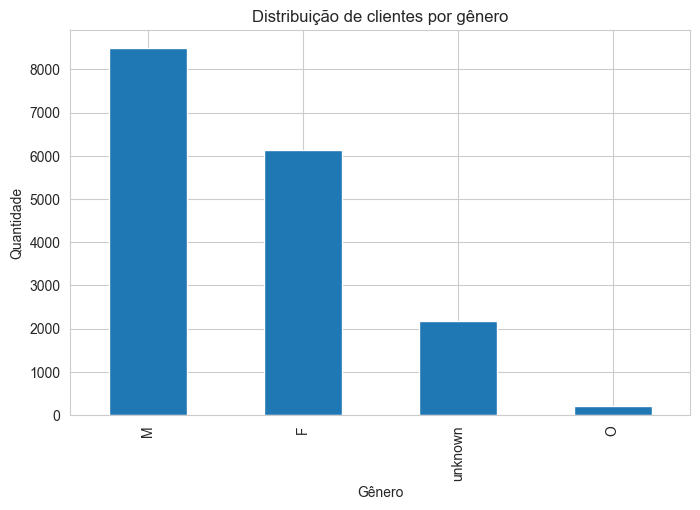

In [13]:
plt.figure(figsize=(8, 5))

customers["gender"].value_counts(dropna=False).plot(
    kind="bar"
)

plt.title("Distribuição de clientes por gênero")
plt.xlabel("Gênero")
plt.ylabel("Quantidade")

plt.show()

## 5.5 Idade da conta

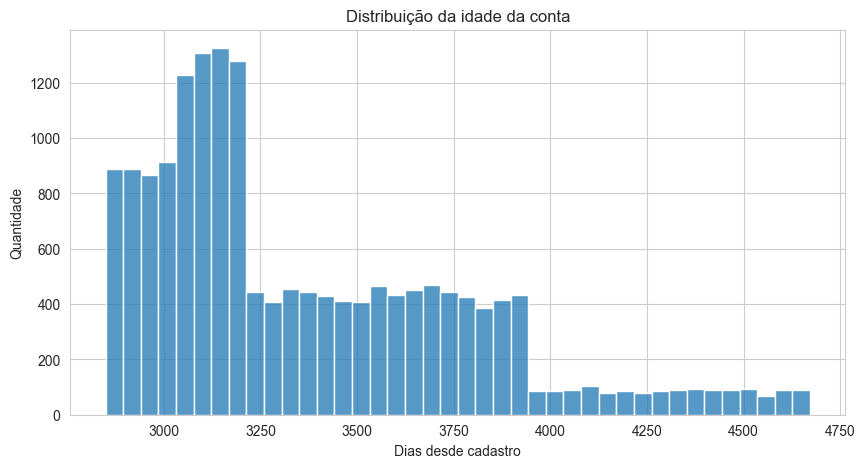

In [14]:
plt.figure(figsize=(10, 5))

sns.histplot(
    customers["account_age_days"],
    bins=40
)

plt.title("Distribuição da idade da conta")
plt.xlabel("Dias desde cadastro")
plt.ylabel("Quantidade")

plt.show()

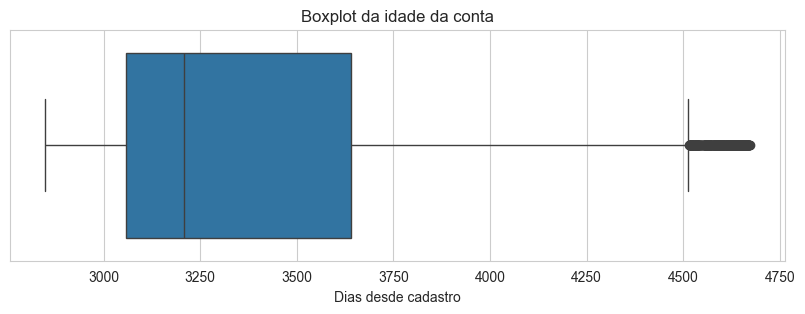

In [15]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    x=customers["account_age_days"]
)

plt.title("Boxplot da idade da conta")
plt.xlabel("Dias desde cadastro")

plt.show()

### Observação

A variável `registered_on` é uma data bruta e foi usada principalmente para derivar `account_age_days`, que representa o tempo de relacionamento do cliente com a plataforma.

# 6. Análise de ofertas

Como o dataset de ofertas possui apenas 10 registros, gráficos de barras e tabelas são mais adequados do que histogramas contínuos.

## 6.1 Tipos de oferta

In [16]:
offers["offer_type"].value_counts()

offer_type
bogo             4
discount         4
informational    2
Name: count, dtype: int64

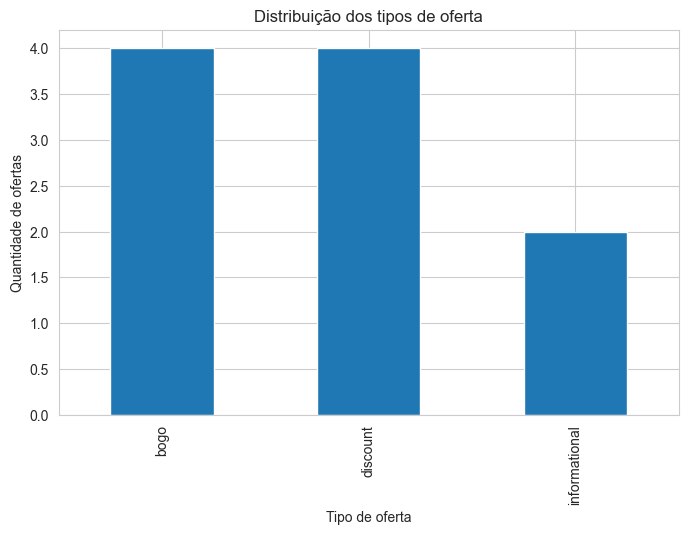

In [17]:
plt.figure(figsize=(8, 5))

offers["offer_type"].value_counts().plot(
    kind="bar"
)

plt.title("Distribuição dos tipos de oferta")
plt.xlabel("Tipo de oferta")
plt.ylabel("Quantidade de ofertas")

plt.show()

## 6.2 Valor de desconto

In [18]:
offers["discount_value"].value_counts().sort_index()

discount_value
0.0     2
2.0     2
3.0     1
5.0     3
10.0    2
Name: count, dtype: int64

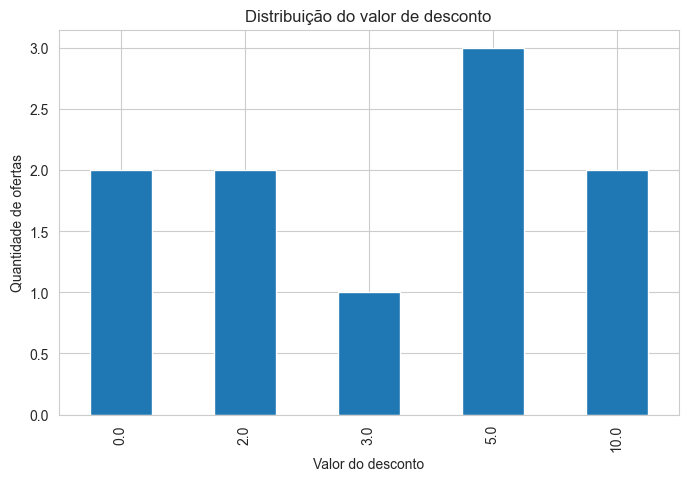

In [19]:
plt.figure(figsize=(8, 5))

offers["discount_value"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Distribuição do valor de desconto")
plt.xlabel("Valor do desconto")
plt.ylabel("Quantidade de ofertas")

plt.show()

## 6.3 Duração das ofertas

In [20]:
offers["duration_days"].value_counts().sort_index()

duration_days
3     1
4     1
5     2
7     4
10    2
Name: count, dtype: int64

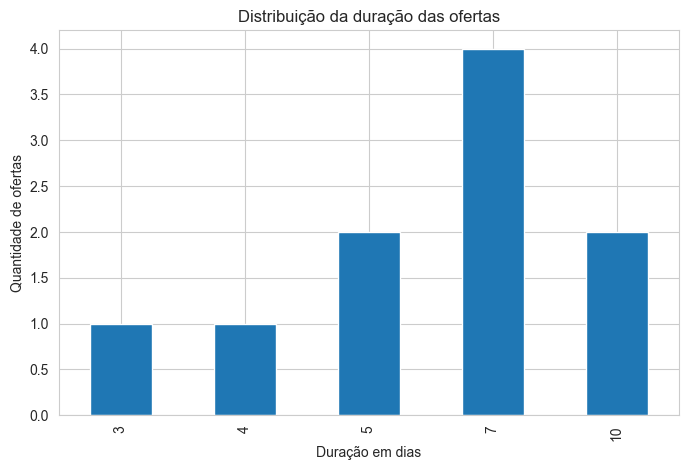

In [21]:
plt.figure(figsize=(8, 5))

offers["duration_days"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Distribuição da duração das ofertas")
plt.xlabel("Duração em dias")
plt.ylabel("Quantidade de ofertas")

plt.show()

## 6.4 Valor mínimo para ativação

In [22]:
offers["min_value"].value_counts().sort_index()

min_value
0.0     2
5.0     2
7.0     1
10.0    4
20.0    1
Name: count, dtype: int64

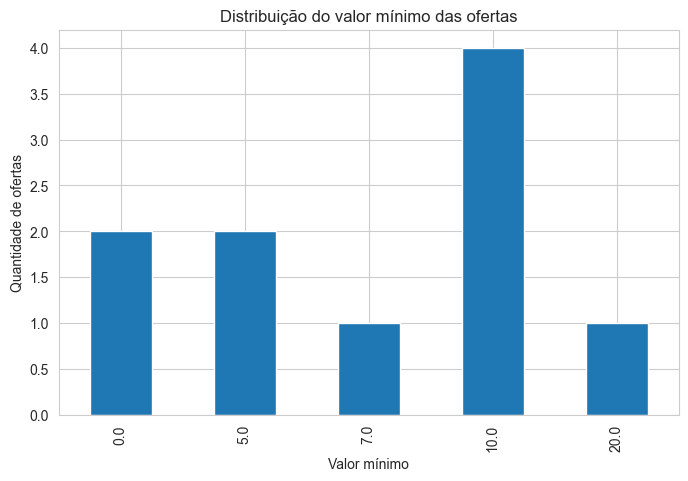

In [23]:
plt.figure(figsize=(8, 5))

offers["min_value"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Distribuição do valor mínimo das ofertas")
plt.xlabel("Valor mínimo")
plt.ylabel("Quantidade de ofertas")

plt.show()

## 6.5 Canais das ofertas

In [24]:
offers_channels["channel"].value_counts()

channel
email     10
mobile     9
web        8
social     6
Name: count, dtype: int64

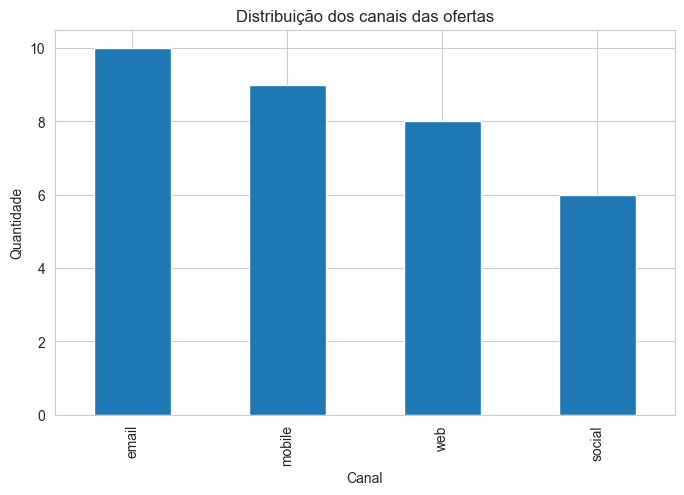

In [25]:
plt.figure(figsize=(8, 5))

offers_channels["channel"].value_counts().plot(
    kind="bar"
)

plt.title("Distribuição dos canais das ofertas")
plt.xlabel("Canal")
plt.ylabel("Quantidade")

plt.show()

# 7. Análise de transações

## 7.1 Distribuição dos eventos

In [26]:
transactions["event"].value_counts()

event
transaction        138953
offer received      76277
offer viewed        57725
offer completed     33579
Name: count, dtype: int64

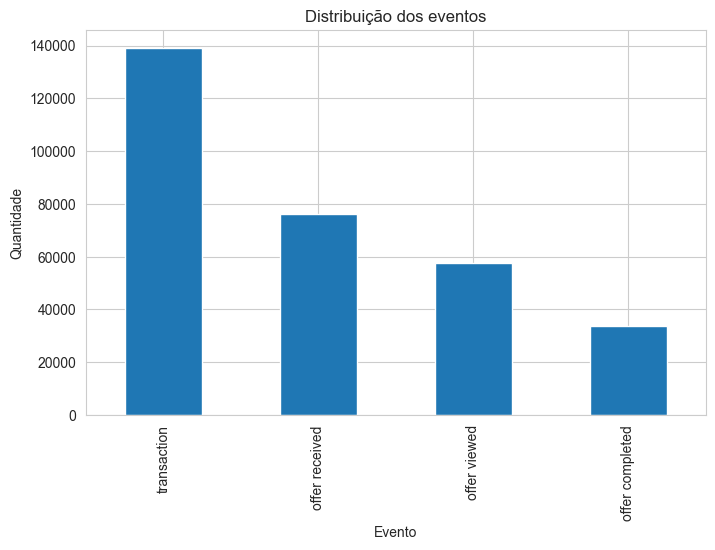

In [27]:
plt.figure(figsize=(8, 5))

transactions["event"].value_counts().plot(
    kind="bar"
)

plt.title("Distribuição dos eventos")
plt.xlabel("Evento")
plt.ylabel("Quantidade")

plt.show()

## 7.2 Valores transacionais

In [28]:
transactions_tx = transactions[
    transactions["event"] == "transaction"
].copy()

transactions_tx["amount"].describe()

count    138953.000000
mean         12.777356
std          30.250529
min           0.050000
25%           2.780000
50%           8.890000
75%          18.070000
max        1062.280000
Name: amount, dtype: float64

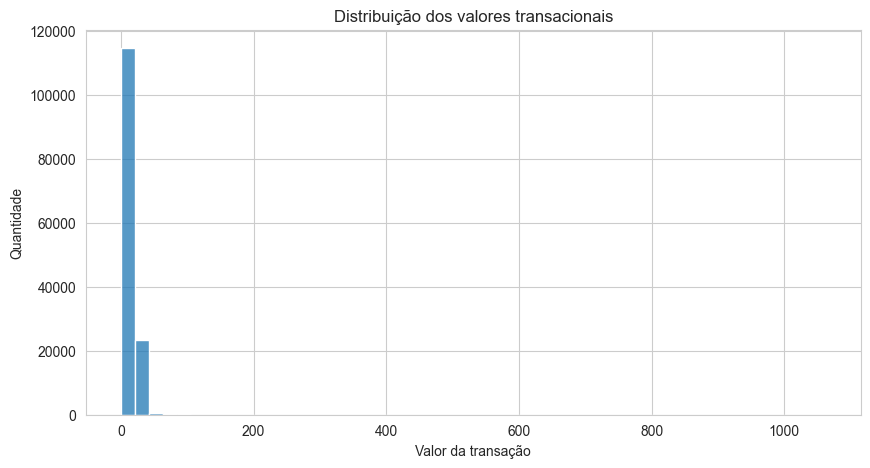

In [29]:
plt.figure(figsize=(10, 5))

sns.histplot(
    transactions_tx["amount"],
    bins=50
)

plt.title("Distribuição dos valores transacionais")
plt.xlabel("Valor da transação")
plt.ylabel("Quantidade")

plt.show()

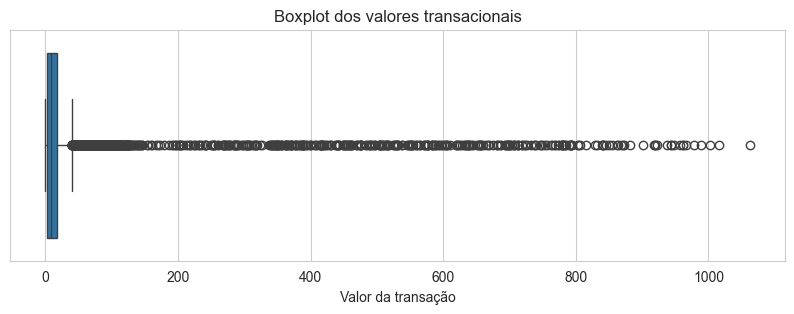

In [30]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    x=transactions_tx["amount"]
)

plt.title("Boxplot dos valores transacionais")
plt.xlabel("Valor da transação")

plt.show()

### Observação

A distribuição dos valores transacionais permite identificar concentração em compras de menor valor e presença de valores mais altos, que podem representar clientes de maior valor para o negócio.

# 8. Funil de ofertas

In [31]:
offer_funnel = (
    transactions[
        transactions["event"].isin([
            "offer received",
            "offer viewed",
            "offer completed"
        ])
    ]
    .groupby("event")
    .size()
    .reindex(["offer received", "offer viewed", "offer completed"])
    .reset_index(name="count")
)

offer_funnel

,event,count
0,offer received,76277
1,offer viewed,57725
2,offer completed,33579


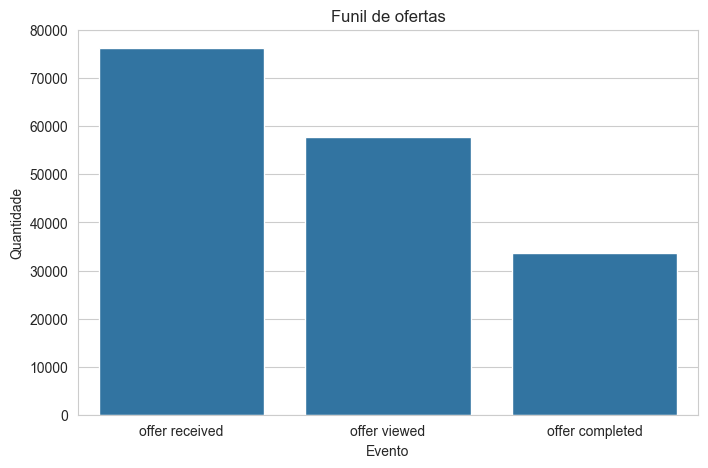

In [32]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=offer_funnel,
    x="event",
    y="count"
)

plt.title("Funil de ofertas")
plt.xlabel("Evento")
plt.ylabel("Quantidade")

plt.show()

In [33]:
received = offer_funnel.loc[
    offer_funnel["event"] == "offer received",
    "count"
].iloc[0]

viewed = offer_funnel.loc[
    offer_funnel["event"] == "offer viewed",
    "count"
].iloc[0]

completed = offer_funnel.loc[
    offer_funnel["event"] == "offer completed",
    "count"
].iloc[0]

print(f"Taxa de visualização: {viewed / received:.2%}")
print(f"Taxa de conclusão: {completed / received:.2%}")
print(f"Conclusão após visualização: {completed / viewed:.2%}")

Taxa de visualização: 75.68%
Taxa de conclusão: 44.02%
Conclusão após visualização: 58.17%


### Observação

O funil permite entender a perda entre recebimento, visualização e conclusão da oferta. Essa etapa é fundamental para diferenciar problemas de exposição da oferta de problemas de atratividade/conversão.

# 9. Análise de outliers

Os outliers foram avaliados antes das segmentações para evitar criação de categorias sem entendimento prévio das distribuições.

In [34]:
numeric_cols = [
    "age",
    "credit_card_limit",
    "account_age_days",
    "total_transactions",
    "total_spent",
    "avg_ticket",
    "min_ticket",
    "max_ticket",
    "offers_received",
    "offers_viewed",
    "offers_completed",
    "view_rate",
    "completion_rate",
    "recency_days"
]

numeric_cols = [
    col for col in numeric_cols
    if col in customer_features.columns
]

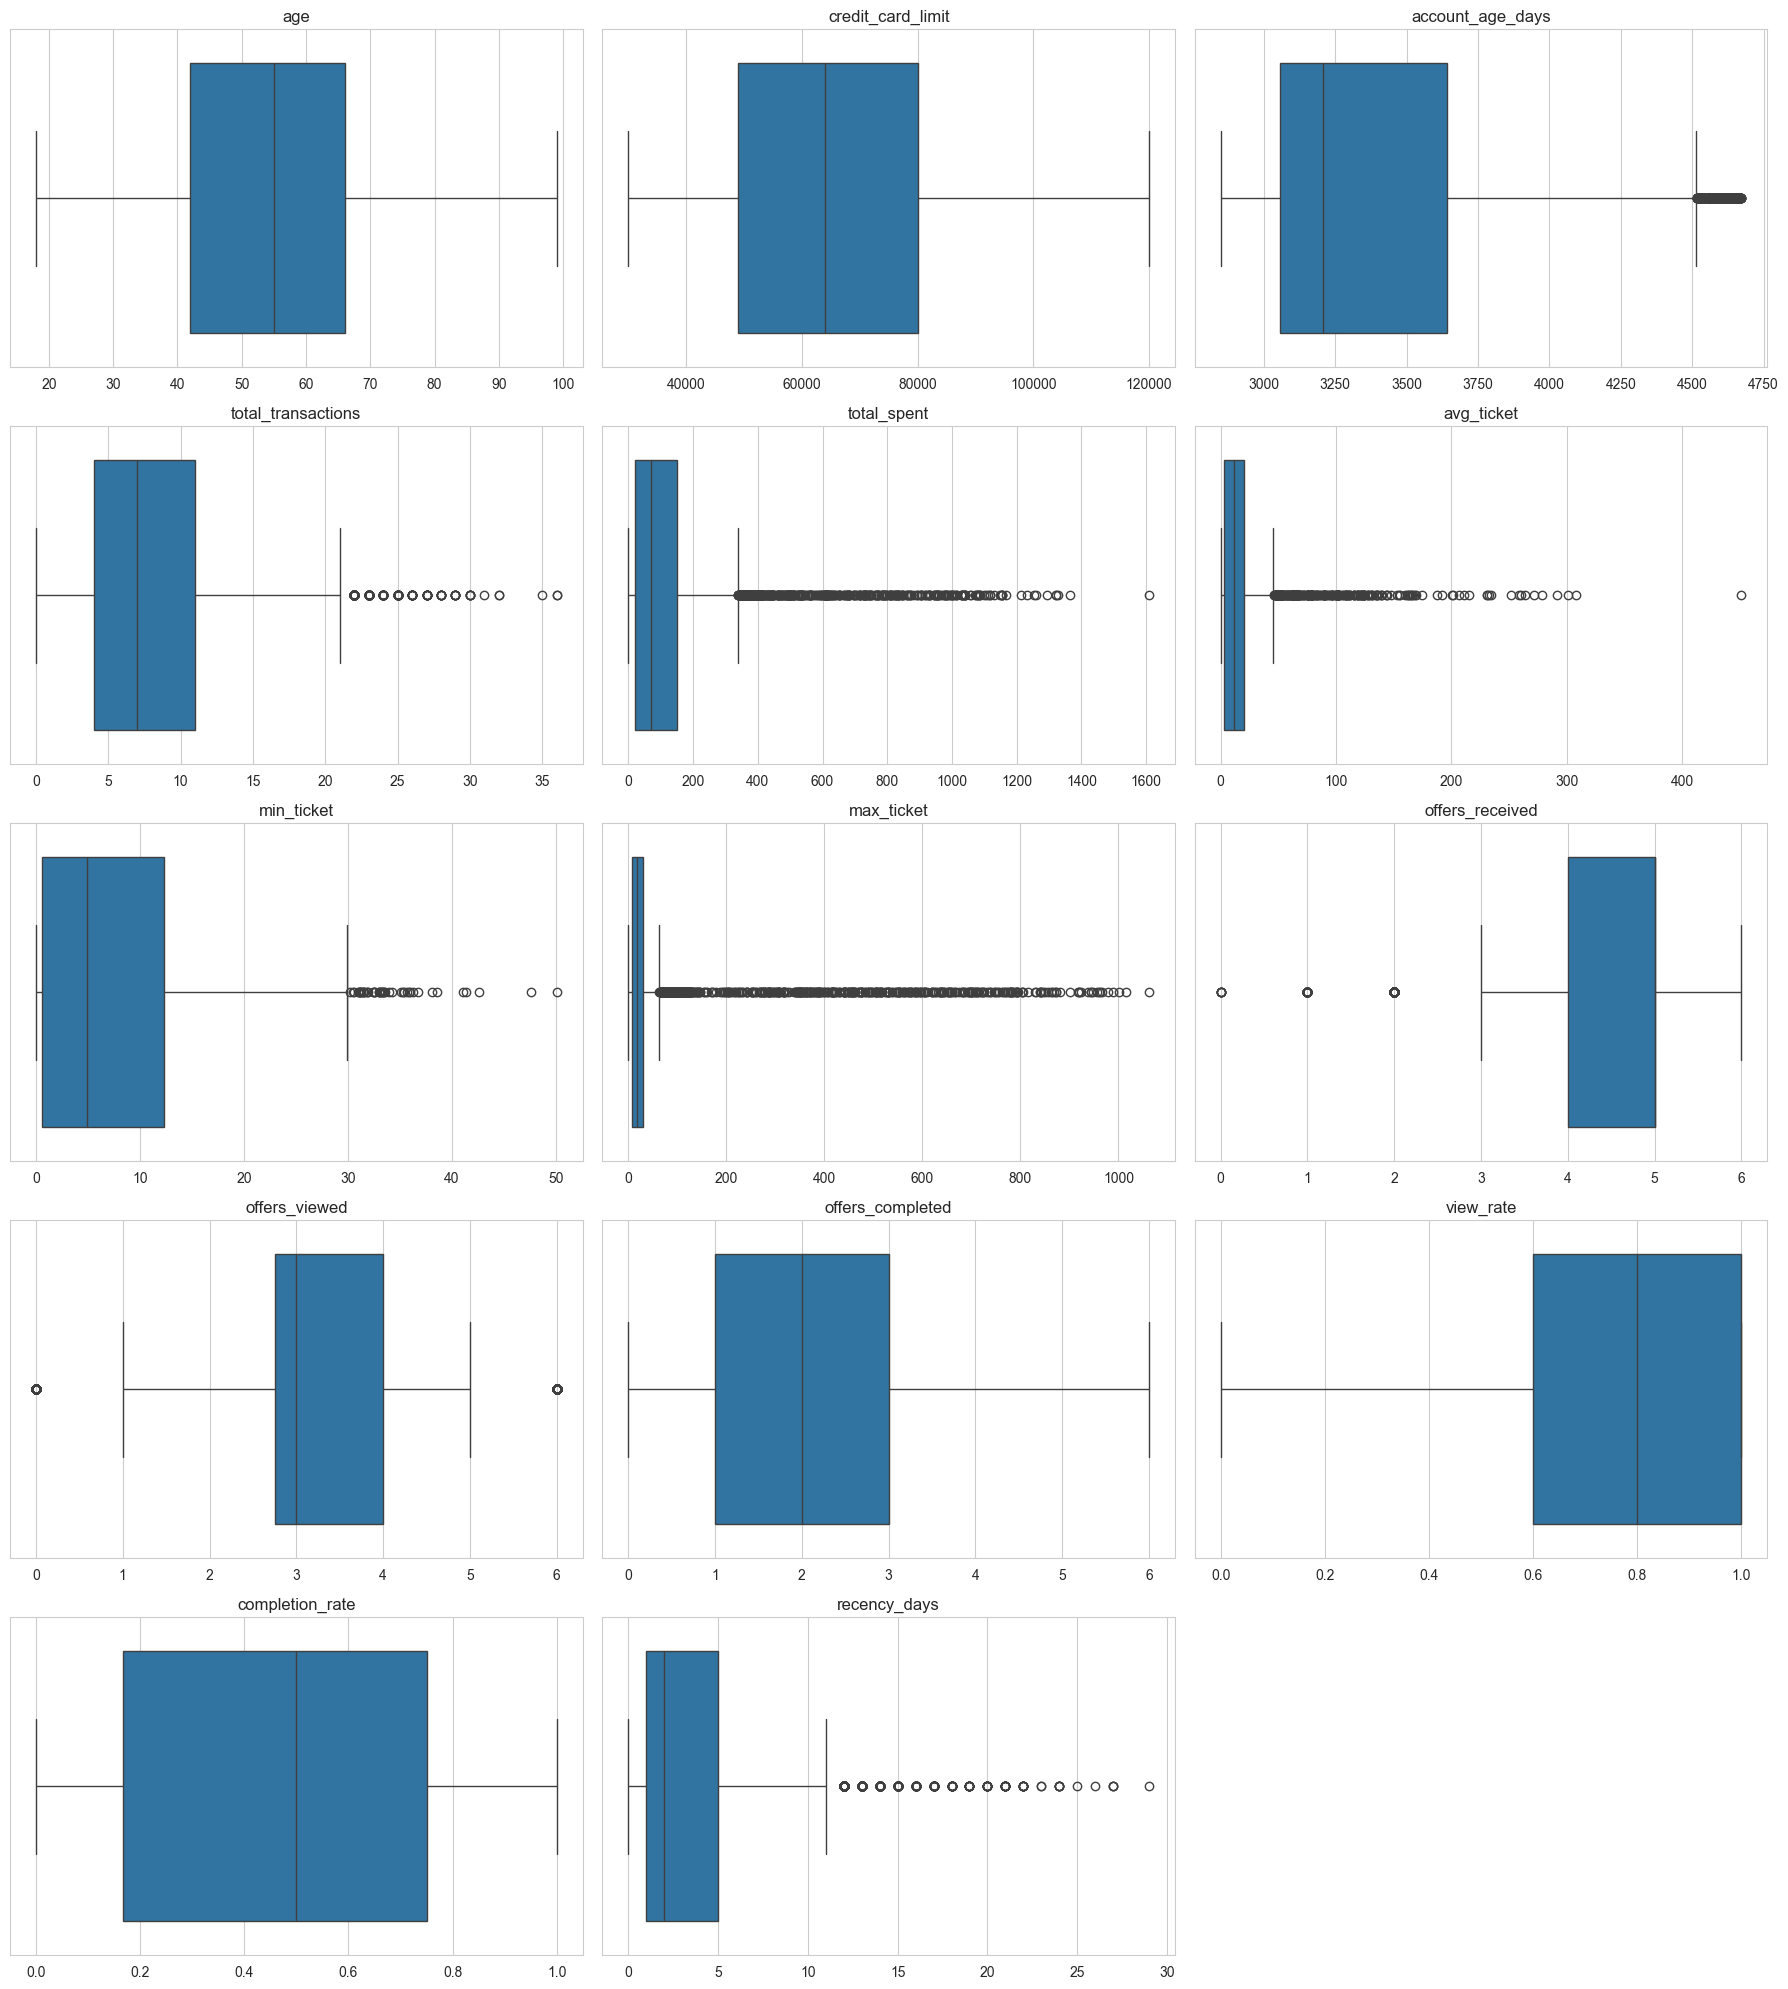

In [35]:
fig, axes = plt.subplots(
    nrows=5,
    ncols=3,
    figsize=(18, 20)
)

axes = axes.flatten()

for i, col_name in enumerate(numeric_cols):
    sns.boxplot(
        x=customer_features[col_name],
        ax=axes[i]
    )

    axes[i].set_title(col_name)
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [36]:
outlier_summary = []

for col_name in numeric_cols:
    q1 = customer_features[col_name].quantile(0.25)
    q3 = customer_features[col_name].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = customer_features[
        (customer_features[col_name] < lower) |
        (customer_features[col_name] > upper)
    ]

    outlier_summary.append({
        "variable": col_name,
        "lower_bound": lower,
        "upper_bound": upper,
        "outliers": len(outliers),
        "percent": round(
            len(outliers) / len(customer_features) * 100,
            2
        )
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.sort_values(
    "percent",
    ascending=False
)

,variable,lower_bound,upper_bound,outliers,percent
9,offers_viewed,8.750000e-01,5.875000,981,5.77
8,offers_received,2.500000e+00,6.500000,689,4.05
7,max_ticket,-2.676500e+01,63.115000,609,3.58
13,recency_days,-5.000000e+00,11.000000,569,3.35
4,total_spent,-1.686238e+02,339.226250,521,3.06
3,total_transactions,-6.500000e+00,21.500000,296,1.74
2,account_age_days,2.182500e+03,4514.500000,287,1.69
5,avg_ticket,-2.276398e+01,46.046635,260,1.53
6,min_ticket,-1.704500e+01,29.955000,48,0.28
0,age,6.000000e+00,102.000000,0,0.00


### Observação

Os outliers identificados parecem representar comportamentos legítimos de clientes de alta atividade e alto consumo, e não necessariamente erros de coleta. Por esse motivo, os valores foram mantidos na análise exploratória. Tratamentos como transformação logarítmica ou clipping poderão ser avaliados posteriormente na etapa de modelagem.

# 10. Transformações logarítmicas

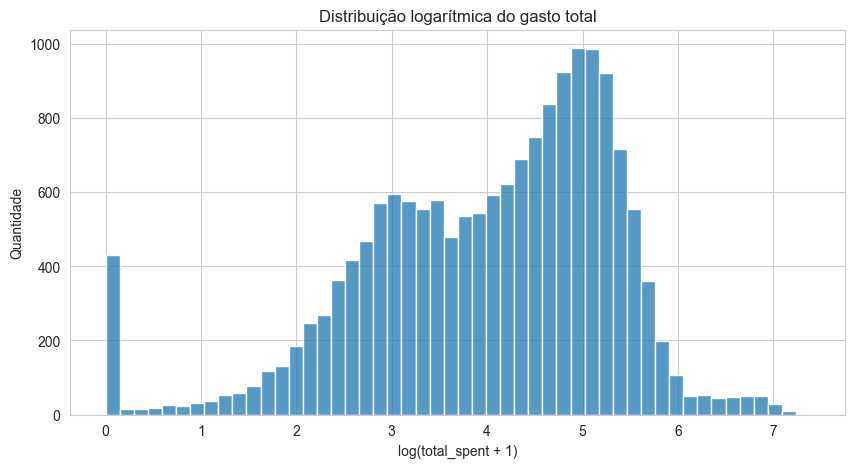

In [37]:
plt.figure(figsize=(10, 5))

sns.histplot(
    np.log1p(customer_features["total_spent"]),
    bins=50
)

plt.title("Distribuição logarítmica do gasto total")
plt.xlabel("log(total_spent + 1)")
plt.ylabel("Quantidade")

plt.show()

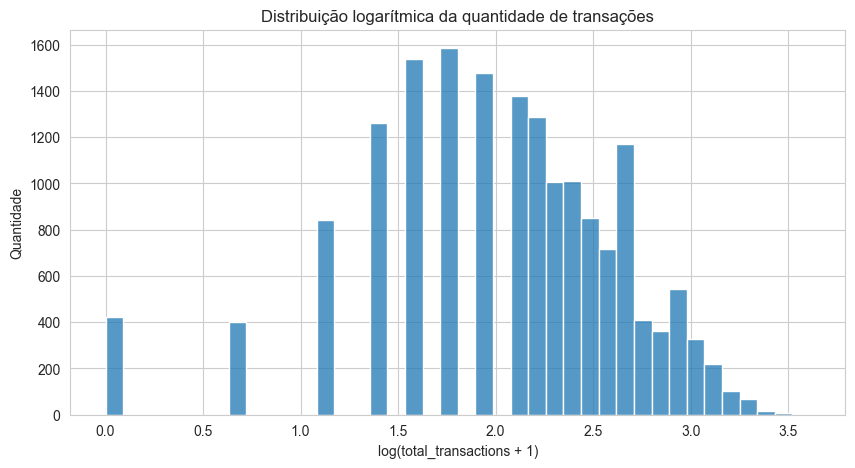

In [38]:
plt.figure(figsize=(10, 5))

sns.histplot(
    np.log1p(customer_features["total_transactions"]),
    bins=40
)

plt.title("Distribuição logarítmica da quantidade de transações")
plt.xlabel("log(total_transactions + 1)")
plt.ylabel("Quantidade")

plt.show()

### Observação

As distribuições originais de gasto total e quantidade de transações apresentam assimetria à direita. A transformação logarítmica reduz a dispersão, facilita comparações e pode ser útil em etapas posteriores de modelagem.

# 11. Correlação entre variáveis numéricas

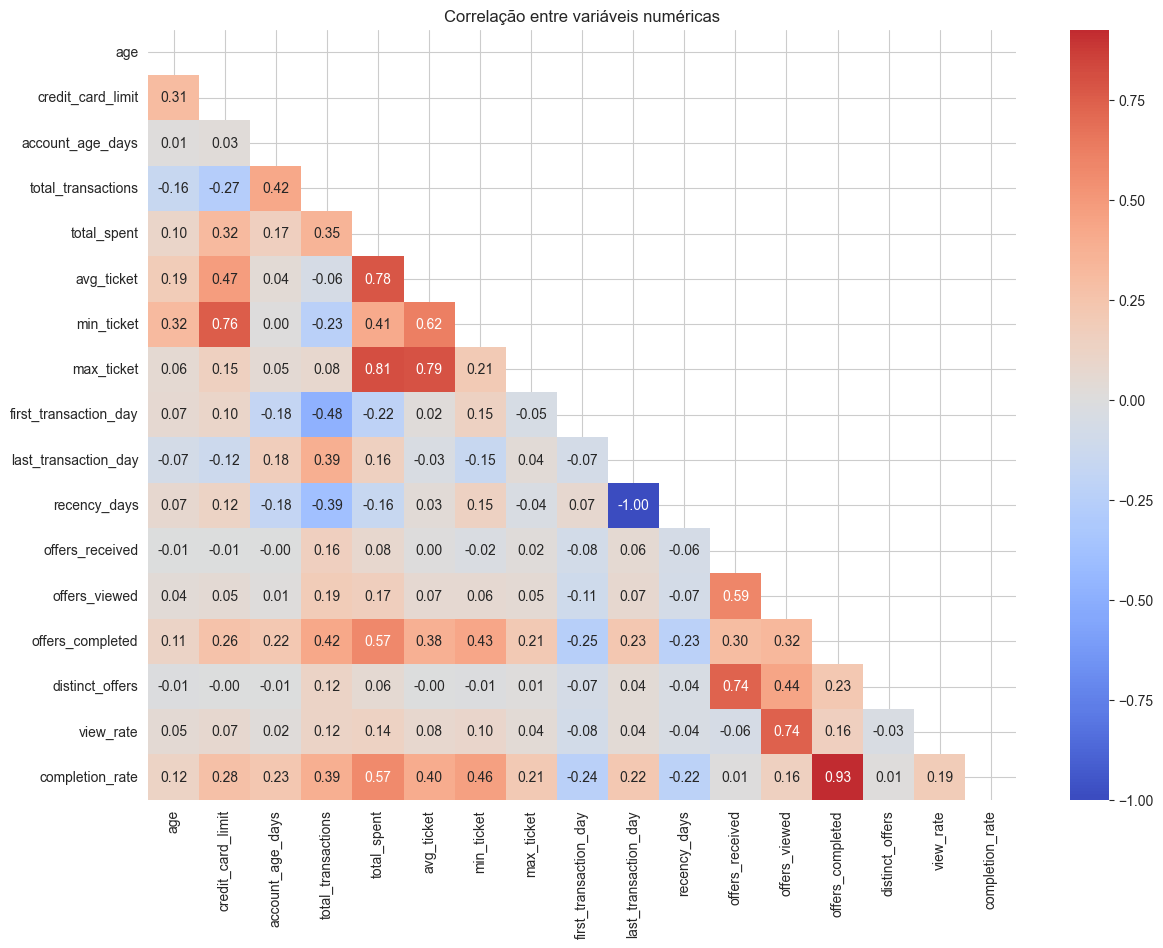

In [39]:
numeric_features = customer_features.select_dtypes(include=["number"])

corr = numeric_features.corr()

plt.figure(figsize=(14, 10))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlação entre variáveis numéricas")

plt.show()

### Observação

Variáveis relacionadas a gasto, recorrência e engajamento promocional apresentam relações relevantes entre si. Também existem variáveis derivadas altamente correlacionadas, o que deverá ser considerado na seleção de features da modelagem.

# 12. Conversão de ofertas

## 12.1 Criação da flag de conversão por cliente

In [41]:
customer_conversion = (
    customer_offer_interactions
    .groupby("account_id")["was_completed"]
    .max()
    .reset_index()
)

customer_conversion.columns = [
    "account_id",
    "converted"
]

eda_customers = customer_features.merge(
    customer_conversion,
    left_on="id",
    right_on="account_id",
    how="left"
)

eda_customers["converted"] = (
    eda_customers["converted"]
    .fillna(0)
    .astype(int)
)

## 12.2 Comparação entre clientes que converteram e não converteram

In [42]:
conversion_summary = (
    eda_customers
    .groupby("converted")
    [
        [
            "total_transactions",
            "total_spent",
            "avg_ticket",
            "offers_received",
            "offers_viewed",
            "completion_rate",
            "recency_days"
        ]
    ]
    .mean()
)

conversion_summary

,total_transactions,total_spent,avg_ticket,offers_received,offers_viewed,completion_rate,recency_days
converted,,,,,,,
0,4.915996,18.039122,4.034437,4.301230,3.043777,0.000000,4.221872
1,9.251448,133.021656,16.419439,4.548301,3.511977,0.585294,2.898309


### Observação

Clientes que converteram ofertas apresentam maior atividade transacional, maior gasto acumulado, maior ticket médio e menor recência. O volume médio de ofertas recebidas é semelhante entre os grupos, sugerindo que o direcionamento das ofertas pode ser mais relevante do que apenas aumentar a quantidade de envios.

## 12.3 Gasto total por conversão

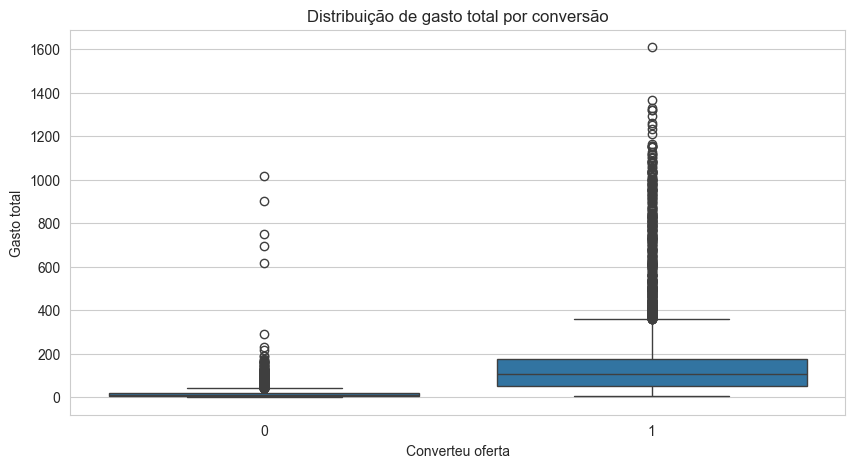

In [43]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=eda_customers,
    x="converted",
    y="total_spent"
)

plt.title("Distribuição de gasto total por conversão")
plt.xlabel("Converteu oferta")
plt.ylabel("Gasto total")

plt.show()

## 12.4 Transações por conversão

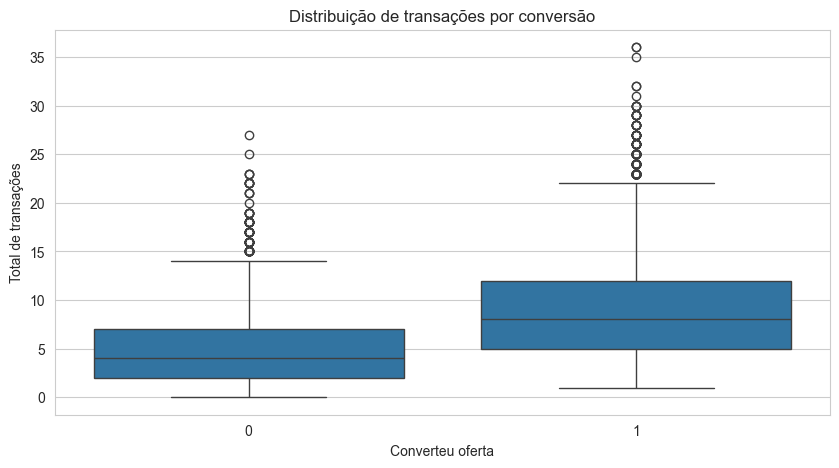

In [44]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=eda_customers,
    x="converted",
    y="total_transactions"
)

plt.title("Distribuição de transações por conversão")
plt.xlabel("Converteu oferta")
plt.ylabel("Total de transações")

plt.show()

## 12.5 Taxa de visualização por conversão

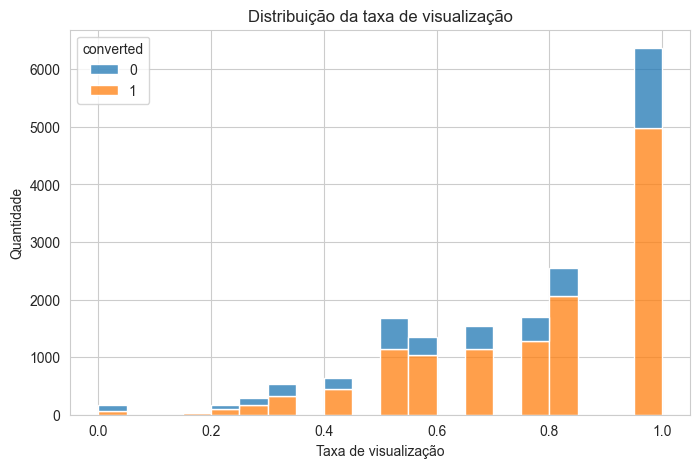

In [45]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=eda_customers,
    x="view_rate",
    hue="converted",
    bins=20,
    multiple="stack"
)

plt.title("Distribuição da taxa de visualização")
plt.xlabel("Taxa de visualização")
plt.ylabel("Quantidade")

plt.show()

### Observação

Clientes que converteram ofertas apresentam concentração maior em taxas elevadas de visualização, indicando que exposição e engajamento com a oferta são sinais importantes para conversão.

# 13. Conversão por atributos da oferta

## 13.1 Conversão por tipo de oferta

In [47]:
offer_conversion = (
    customer_offer_interactions
    .groupby("offer_type")
    .agg(
        conversion_rate=("was_completed", "mean"),
        view_rate=("was_viewed", "mean"),
        total_offers=("offer_id", "count")
    )
    .reset_index()
    .sort_values("conversion_rate", ascending=False)
)

offer_conversion

,offer_type,conversion_rate,view_rate,total_offers
1,discount,0.732539,0.823202,48366
0,bogo,0.657649,0.909789,48608
2,informational,0.000000,0.799302,18635


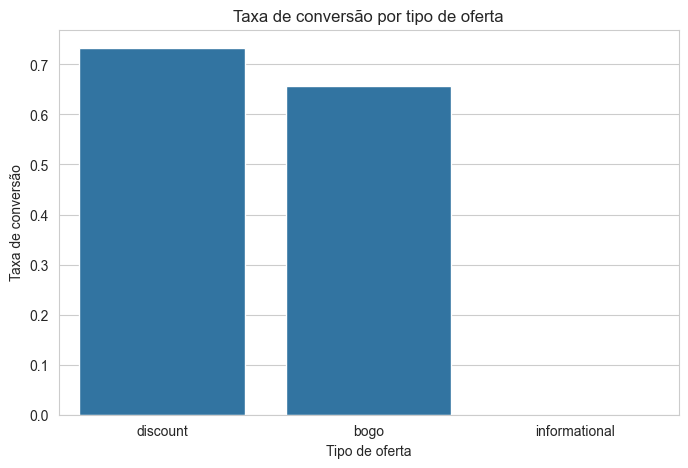

In [48]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=offer_conversion,
    x="offer_type",
    y="conversion_rate"
)

plt.title("Taxa de conversão por tipo de oferta")
plt.xlabel("Tipo de oferta")
plt.ylabel("Taxa de conversão")

plt.show()

## 13.2 Conversão por canal

In [50]:
channel_analysis = (
    customer_offer_interactions
    .merge(
        offers_channels,
        left_on="offer_id",
        right_on="id",
        how="left"
    )
)

channel_conversion = (
    channel_analysis
    .groupby("channel")
    .agg(
        conversion_rate=("was_completed", "mean"),
        total=("offer_id", "count")
    )
    .reset_index()
    .sort_values("conversion_rate", ascending=False)
)

channel_conversion

,channel,conversion_rate,total
3,web,0.639237,93341
2,social,0.622283,75554
1,mobile,0.584768,106078
0,email,0.582974,115609


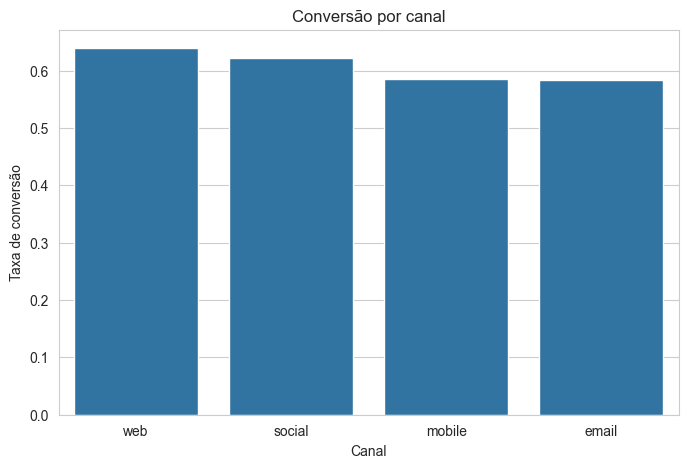

In [51]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=channel_conversion,
    x="channel",
    y="conversion_rate"
)

plt.title("Conversão por canal")
plt.xlabel("Canal")
plt.ylabel("Taxa de conversão")

plt.show()

### Observação

A análise por tipo de oferta e canal ajuda a identificar quais características das campanhas estão associadas a maior engajamento e conversão.

# 14. Segmentações analíticas

As faixas foram criadas após a avaliação das distribuições. Para reduzir arbitrariedade, foram utilizados quantis, garantindo grupos mais balanceados para comparação.

## 14.1 Criação de grupos por quantis

In [52]:
customers_segmented = customers.copy()

customers_segmented["age_group"] = pd.qcut(
    customers_segmented["age"].rank(method="first"),
    q=4,
    labels=[
        "Q1",
        "Q2",
        "Q3",
        "Q4"
    ]
)

customers_segmented["credit_card_limit_group"] = pd.qcut(
    customers_segmented["credit_card_limit"].rank(method="first"),
    q=4,
    labels=[
        "low",
        "medium_low",
        "medium_high",
        "high"
    ]
)

In [53]:
customers_segmented.groupby("age_group")["age"].describe()

/var/folders/64/hyg0ph7s3116ly86l0fv6gr00000gn/T/ipykernel_26283/1753214.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  customers_segmented.groupby("age_group")["age"].describe()


,count,mean,std,min,25%,50%,75%,max
age_group,,,,,,,,
Q1,3702.0,31.153971,7.281395,18.0,25.0,32.0,38.0,42.0
Q2,3702.0,49.612642,3.607032,42.0,47.0,50.0,53.0,55.0
Q3,3702.0,60.589681,3.190084,55.0,58.0,60.0,63.0,66.0
Q4,3702.0,76.007023,7.467480,66.0,70.0,74.0,81.0,99.0


In [54]:
customers_segmented.groupby("credit_card_limit_group")[
    "credit_card_limit"
].describe()

/var/folders/64/hyg0ph7s3116ly86l0fv6gr00000gn/T/ipykernel_26283/360267929.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  customers_segmented.groupby("credit_card_limit_group")[


,count,mean,std,min,25%,50%,75%,max
credit_card_limit_group,,,,,,,,
low,3707.0,39226.868087,5495.035387,30000.0,34000.0,39000.0,44000.0,49000.0
medium_low,3706.0,56182.676740,4079.153674,49000.0,53000.0,56000.0,60000.0,64000.0
medium_high,3706.0,71143.820831,4319.817294,64000.0,67000.0,71000.0,74000.0,80000.0
high,3706.0,95073.664328,10807.266132,80000.0,86000.0,93000.0,102000.0,120000.0


## 14.2 Conversão por faixa etária

In [55]:
age_conversion = (
    eda_customers
    .merge(
        customers_segmented[["id", "age_group"]],
        on="id",
        how="left"
    )
    .groupby("age_group")
    .agg(
        conversion_rate=("converted", "mean"),
        avg_spent=("total_spent", "mean"),
        avg_transactions=("total_transactions", "mean"),
        total_customers=("id", "count")
    )
    .reset_index()
)

age_conversion

/var/folders/64/hyg0ph7s3116ly86l0fv6gr00000gn/T/ipykernel_26283/2681361823.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eda_customers


,age_group,conversion_rate,avg_spent,avg_transactions,total_customers
0,Q1,0.740681,94.805057,9.962183,3702
1,Q2,0.816045,116.916548,7.980551,3702
2,Q3,0.844679,127.873252,7.757969,3702
3,Q4,0.831713,128.268928,7.741221,3702


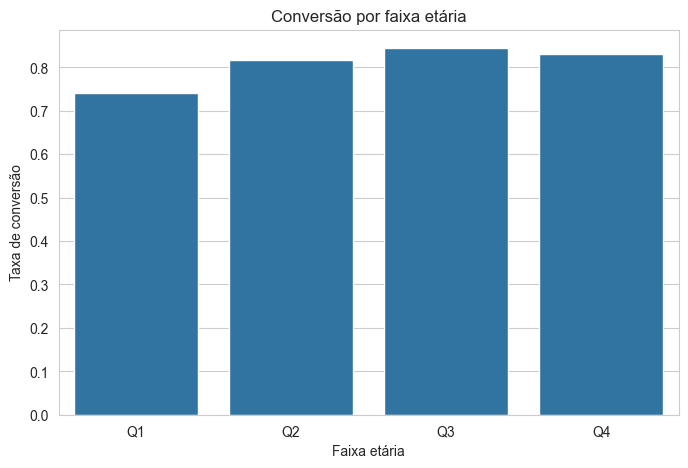

In [56]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=age_conversion,
    x="age_group",
    y="conversion_rate"
)

plt.title("Conversão por faixa etária")
plt.xlabel("Faixa etária")
plt.ylabel("Taxa de conversão")

plt.show()

## 14.3 Conversão por faixa de limite de crédito

In [57]:
credit_conversion = (
    eda_customers
    .merge(
        customers_segmented[
            ["id", "credit_card_limit_group"]
        ],
        on="id",
        how="left"
    )
    .groupby("credit_card_limit_group")
    .agg(
        conversion_rate=("converted", "mean"),
        avg_spent=("total_spent", "mean"),
        avg_transactions=("total_transactions", "mean"),
        total_customers=("id", "count")
    )
    .reset_index()
)

credit_conversion

/var/folders/64/hyg0ph7s3116ly86l0fv6gr00000gn/T/ipykernel_26283/3739454372.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eda_customers


,credit_card_limit_group,conversion_rate,avg_spent,avg_transactions,total_customers
0,low,0.680065,66.658015,10.025088,3707
1,medium_low,0.778198,96.909158,8.982731,3706
2,medium_high,0.843227,127.771444,8.155963,3706
3,high,0.932542,176.787596,6.281166,3706


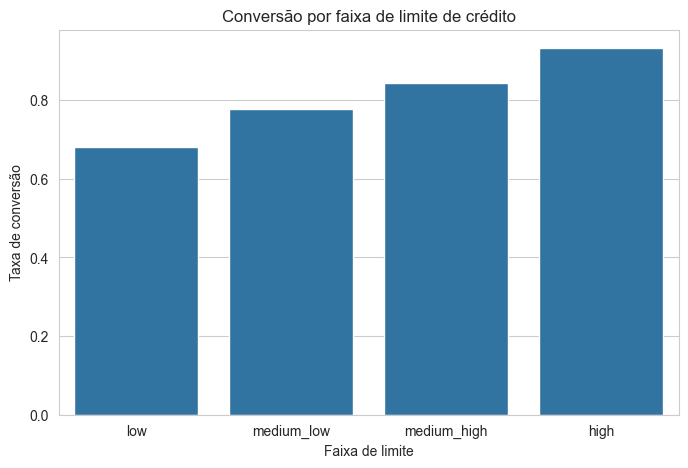

In [58]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=credit_conversion,
    x="credit_card_limit_group",
    y="conversion_rate"
)

plt.title("Conversão por faixa de limite de crédito")
plt.xlabel("Faixa de limite")
plt.ylabel("Taxa de conversão")

plt.show()

# 15. Clientes mais valiosos

In [59]:
top_customers = (
    customer_features
    .sort_values("total_spent", ascending=False)
    .head(10)
)

top_customers[
    [
        "id",
        "total_spent",
        "total_transactions",
        "avg_ticket",
        "completion_rate",
        "view_rate",
        "recency_days"
    ]
]

,id,total_spent,total_transactions,avg_ticket,completion_rate,view_rate,recency_days
12617,3c8d541112a74af99e88abbd0692f00e,1608.69,8,201.086250,1.000000,1.000000,2.0
233,f1d65ae63f174b8f80fa063adcaa63b7,1365.66,13,105.050769,1.000000,0.833333,1.0
6959,ae6f43089b674728a50b8727252d3305,1327.74,16,82.983750,0.600000,0.600000,4.0
6958,626df8678e2a4953b9098246418c9cfa,1321.42,13,101.647692,0.800000,0.600000,2.0
14952,73afdeca19e349b98f09e928644610f8,1319.97,10,131.997000,1.000000,0.600000,1.0
15143,52959f19113e4241a8cb3bef486c6412,1292.86,12,107.738333,0.833333,0.666667,0.0
394,ad1f0a409ae642bc9a43f31f56c130fc,1258.19,5,251.638000,0.500000,0.833333,8.0
8399,d240308de0ee4cf8bb6072816268582b,1251.99,14,89.427857,0.833333,1.000000,3.0
1292,946fc0d3ecc4492aa4cc06cf6b1492c3,1232.40,17,72.494118,0.800000,1.000000,0.0
4668,6406abad8e2c4b8584e4f68003de148d,1211.76,12,100.980000,1.000000,1.000000,4.0


### Observação

A identificação de clientes de maior valor permite avaliar perfis com alto potencial de retorno e apoiar estratégias diferenciadas de retenção, recompensa ou comunicação.

# 16. Target final para modelagem

In [60]:
eda_customers["converted"].value_counts()

converted
1    12774
0     4226
Name: count, dtype: int64

In [61]:
eda_customers["converted"].value_counts(normalize=True)

converted
1    0.751412
0    0.248588
Name: proportion, dtype: float64

### Observação

A distribuição da variável alvo indica o grau de balanceamento entre clientes que converteram e não converteram ofertas. Esse ponto será considerado na etapa de modelagem.

# 17. Principais conclusões da análise exploratória

- Clientes com maior atividade transacional apresentam maior propensão à conversão de ofertas.

- O volume de ofertas recebidas é semelhante entre clientes que convertem e não convertem, sugerindo que o direcionamento das ofertas é mais relevante do que a quantidade de envios.

- Taxas de visualização e conclusão possuem relação com comportamento de compra e engajamento promocional.

- Variáveis monetárias e transacionais apresentam distribuições assimétricas, com presença de clientes altamente ativos e de alto valor.

- As transformações logarítmicas reduziram a dispersão das variáveis e facilitaram a análise comparativa.

- Foram identificadas correlações relevantes entre métricas de engajamento, gasto e conversão, indicando potencial preditivo para modelos supervisionados.

- Os outliers observados aparentam representar comportamentos legítimos de clientes de alto consumo, sendo mantidos para preservar variabilidade comportamental.

# 18. Próximos passos

A próxima etapa do projeto consiste na construção de modelos preditivos para estimar a probabilidade de conversão de ofertas, utilizando as variáveis comportamentais e transacionais identificadas durante a análise exploratória.

Também poderão ser avaliadas:

- seleção de features;
- tratamento adicional de variáveis correlacionadas;
- técnicas de balanceamento;
- segmentação de clientes;
- comparação entre algoritmos supervisionados.